In [2]:
try:
    import pyspark
except ImportError:
    !pip -q install pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType

spark = (
    SparkSession.builder
    .appName("JoinWithDataFrames")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

Δημιουργία Dataset

In [3]:
data_R = [
    ("R1", "GR"),
    ("R2", "GR"),
    ("R3", "US"),
    ("R4", "US"),
    ("R5", "DE")
]

data_S = [
    ("S1", "GR"),
    ("S2", "US"),
    ("S3", "US"),
    ("S4", "DE")
]

dfR = spark.createDataFrame(data_R, ["R_ID", "country"])
dfS = spark.createDataFrame(data_S, ["S_ID", "country"])

dfR.show()
dfS.show()

+----+-------+
|R_ID|country|
+----+-------+
|  R1|     GR|
|  R2|     GR|
|  R3|     US|
|  R4|     US|
|  R5|     DE|
+----+-------+

+----+-------+
|S_ID|country|
+----+-------+
|  S1|     GR|
|  S2|     US|
|  S3|     US|
|  S4|     DE|
+----+-------+



Εκτέλεση Join με DataFrames

In [4]:
df_join = (
    dfR.join(dfS, on="country", how="inner")
        .select("country", "S_ID", "R_ID")
)

df_join.show()

+-------+----+----+
|country|S_ID|R_ID|
+-------+----+----+
|     DE|  S4|  R5|
|     GR|  S1|  R1|
|     GR|  S1|  R2|
|     US|  S2|  R3|
|     US|  S3|  R3|
|     US|  S2|  R4|
|     US|  S3|  R4|
+-------+----+----+



Πλήθος αποτελεσμάτων ανά χώρα

In [5]:
df_counts = (
    df_join
    .groupBy("country")
    .count()
    .orderBy(F.desc("count"))
)

df_counts.show()

+-------+-----+
|country|count|
+-------+-----+
|     US|    4|
|     GR|    2|
|     DE|    1|
+-------+-----+



Μετατροπή σε pandas

In [6]:
pdf = df_counts.toPandas()
pdf

,country,count
0,US,4
1,GR,2
2,DE,1


Διάγραμμα

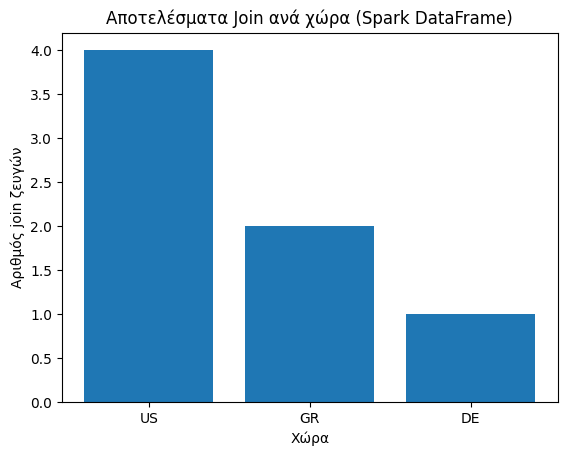

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(pdf["country"], pdf["count"])
plt.xlabel("Χώρα")
plt.ylabel("Αριθμός join ζευγών")
plt.title("Αποτελέσματα Join ανά χώρα (Spark DataFrame)")
plt.show()

Μέτρηση χρόνου

In [8]:
import time

start = time.time()
_ = df_join.count()
end = time.time()

print("Χρόνος εκτέλεσης join (DataFrame):",
      round(end - start, 4), "δευτ.")

Χρόνος εκτέλεσης join (DataFrame): 1.2682 δευτ.


#Συμπέρασμα
Η σύζευξη των συνόλων R και S υλοποιήθηκε με χρήση Spark DataFrames
πάνω στο πεδίο country. Τα αποτελέσματα εμφανίζονται σωστά σε μορφή
πίνακα και διαγράμματος, ενώ η χώρα US παράγει περισσότερα ζεύγη,
γεγονός που δείχνει ανισοκατανομή τιμών. Η χρήση DataFrames απλοποιεί
την υλοποίηση και προσφέρει καθαρή παρουσίαση των αποτελεσμάτων.